<a href="https://colab.research.google.com/github/JWasonga/Statistical_Data_Analytics/blob/Applied_Statistics_and_Econometrics-_Portfolio/2_machineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Downloading Libraries

In [1]:
! pip install nltk
! pip install vaderSentiment
! pip install pytrends
! pip install textblob
! pip install wordcloud
! pip install gensim
! pip install seaborn
! pip install TextBlob
! pip install joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 13.5 MB/s eta 0:00:00


##Importing Libraries

In [8]:
import nltk
import seaborn as sns
import logging
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
import re
import string
import joblib
from textblob import TextBlob

from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [9]:
##NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('wordnet', quiet = True)
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

##Importing Dataset

In [10]:
from google.colab import files
uploaded = files.upload()

Saving reviews.txt to reviews.txt


In [11]:
df = pd.read_csv("reviews.txt")
df.head()

,date,reviewer_name,comments,cleaned_comments,polarity,sentiment
0,2016-08-20,Jenny,"Die Unterkunft war wirklicht toll, ruhig, nett...",die unterkunft war wirklicht toll ruhig nett z...,-0.7,negative
1,2023-01-08,Elia,"El apartamento estaba correcto, tal cual, como...",el apartamento estaba correcto tal cual como e...,-0.6,negative
2,2023-05-02,Cecilia,Yo buscaba estar cerca de la estación de Liver...,yo buscaba estar cerca de la estación de liver...,-0.6,negative
3,2018-11-25,Sibylle,"Elisas Wohnung liegt in Hampsted, mehrere Busl...",elisa wohnung liegt hampst mehrer buslinien ha...,-0.7,negative
4,2018-02-18,Nathalie,Ich habe meinen Aufenthalt bei Hedge und Britt...,ich habe meinen aufenthalt bei hedg und britt ...,-0.7,negative


In [12]:
df.columns

Index(['date', 'reviewer_name', 'comments', 'cleaned_comments', 'polarity',
       'sentiment'],
      dtype='object')

In [13]:
df.shape

(11588, 6)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11588 entries, 0 to 11587
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              11588 non-null  object 
 1   reviewer_name     11588 non-null  object 
 2   comments          11588 non-null  object 
 3   cleaned_comments  11588 non-null  object 
 4   polarity          11588 non-null  float64
 5   sentiment         11588 non-null  object 
dtypes: float64(1), object(5)
memory usage: 543.3+ KB


In [15]:
df.isnull().sum()

,0
date,0
reviewer_name,0
comments,0
cleaned_comments,0
polarity,0
sentiment,0


##Exploratory Data Analysis

In [16]:
reviewer_freq = df['reviewer_name'].value_counts()
reviewer_freq

,count
reviewer_name,
David,86
Michael,71
Laura,70
Daniel,63
Sarah,59
...,...
Calla,1
Ilya,1
Keah,1


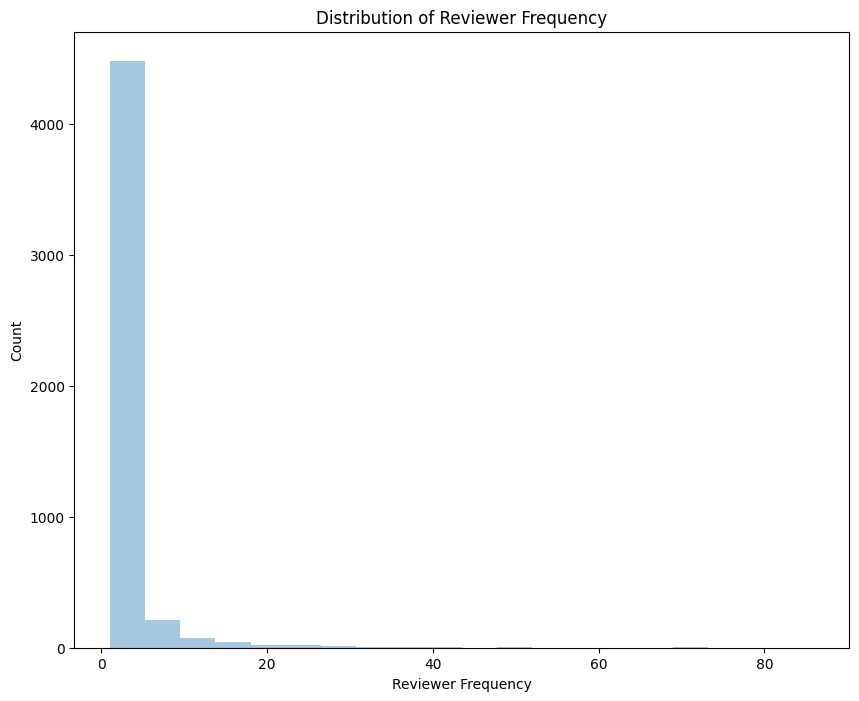

In [17]:
#Plot the distribution of reviewer frequency using seaborn
plt.figure(figsize=(10, 8))
sns.distplot(reviewer_freq, kde=False, bins=20)
plt.title('Distribution of Reviewer Frequency')
plt.xlabel('Reviewer Frequency')
plt.ylabel('Count')
plt.show()

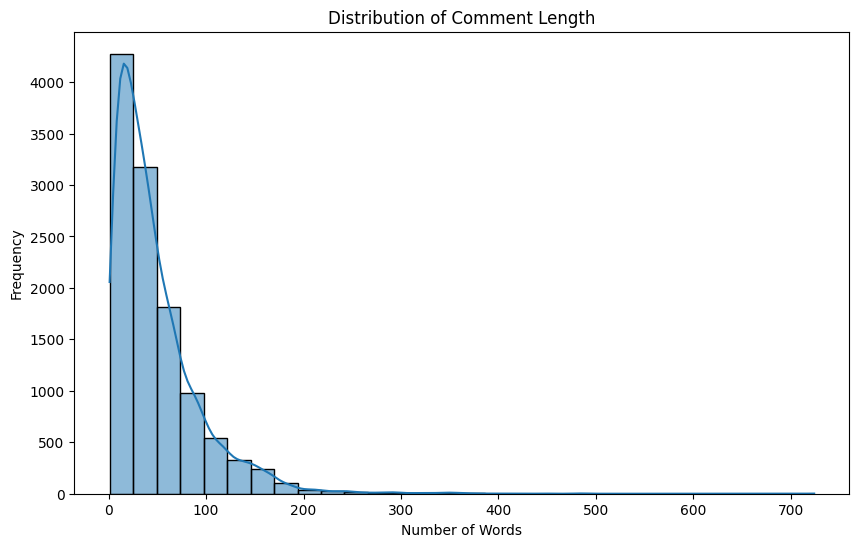

In [18]:
df['cleaned_comments'] = df['comments'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 6))
sns.histplot(df['cleaned_comments'], bins = 30, kde = True)
plt.title('Distribution of Comment Length')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

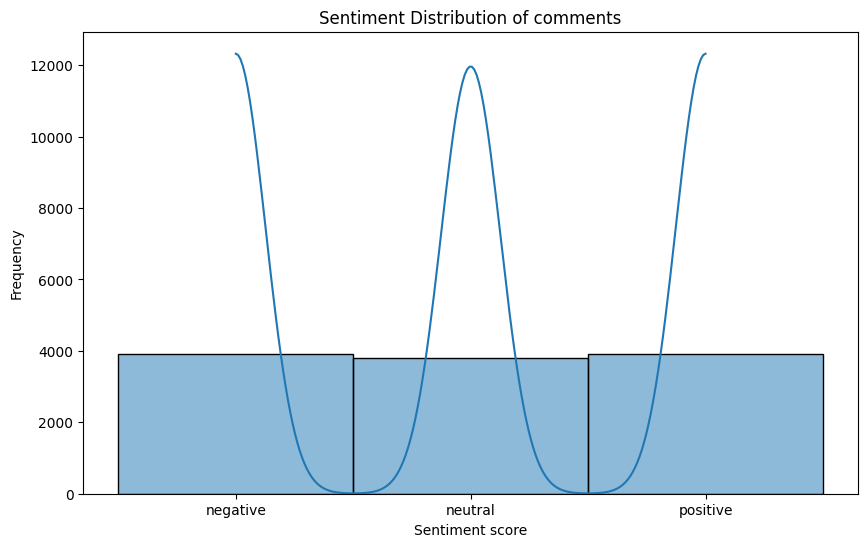

In [19]:
#Visualizing Sentiment Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment'], bins=30, kde=True)
plt.title('Sentiment Distribution of comments')
plt.xlabel('Sentiment score')
plt.ylabel('Frequency')
plt.show()

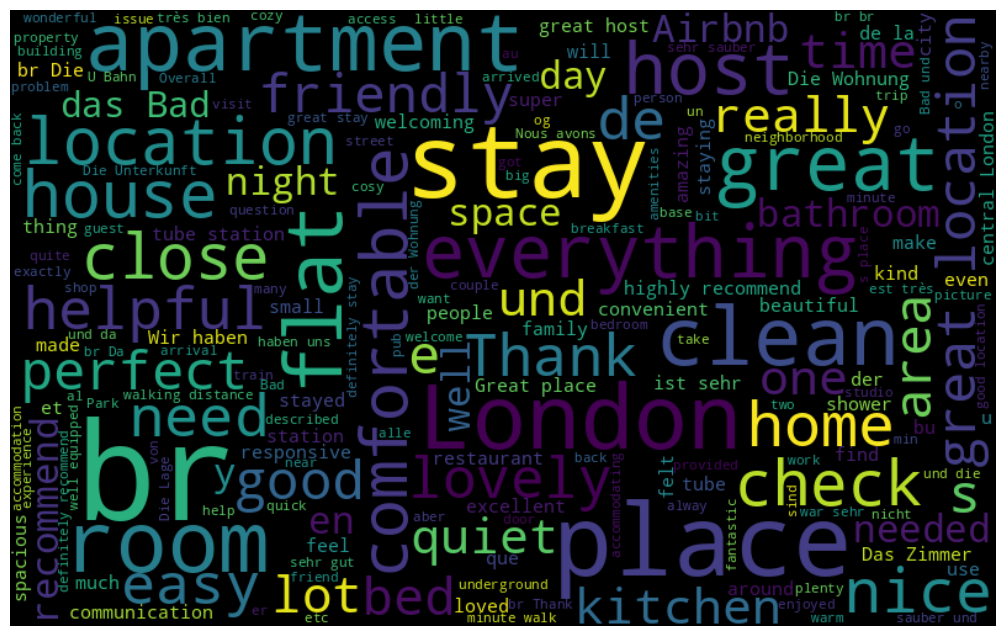

In [20]:
#Word Frequency Analysis
all_words = ' '.join(df['comments'].astype(str))
from wordcloud import WordCloud
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(all_words)
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

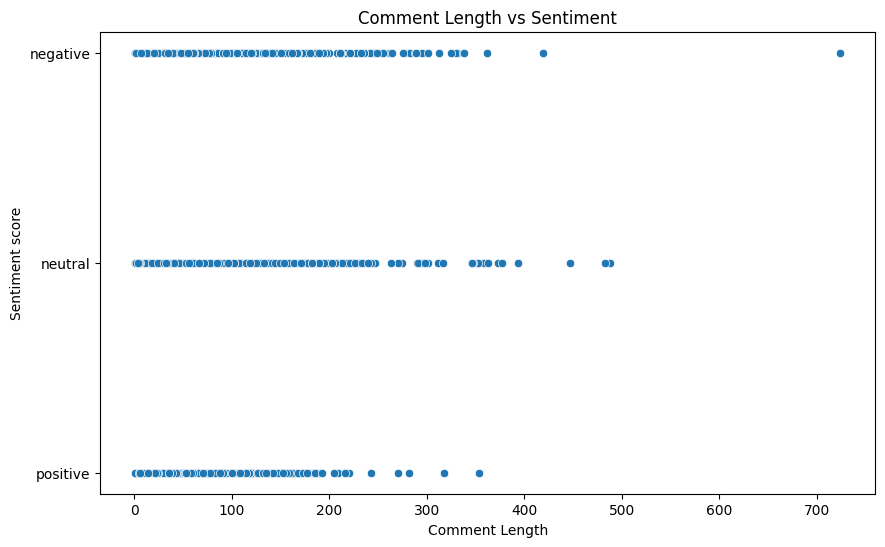

In [21]:
#Comment length vs Sentiment
plt.figure(figsize=(10, 6))
sns.scatterplot(x='cleaned_comments', y='sentiment', data=df)
plt.title('Comment Length vs Sentiment')
plt.xlabel('Comment Length')
plt.ylabel('Sentiment score')
plt.show()

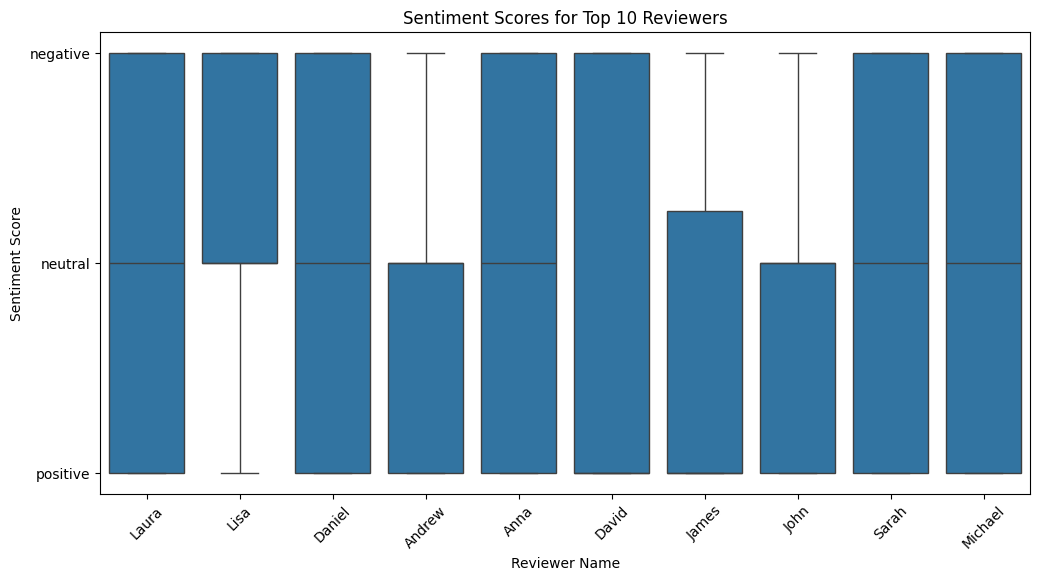

In [22]:
#Reviewer Frequency and Sentiment
#Top 10 reviwers
top_10_reviewers = df['reviewer_name'].value_counts().head(10).index
top_10_reviewers_df = df[df['reviewer_name'].isin(top_10_reviewers)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='reviewer_name', y ='sentiment', data=top_10_reviewers_df)
plt.xticks(rotation=45)
plt.title('Sentiment Scores for Top 10 Reviewers')
plt.xlabel('Reviewer Name')
plt.ylabel('Sentiment Score')
plt.show()

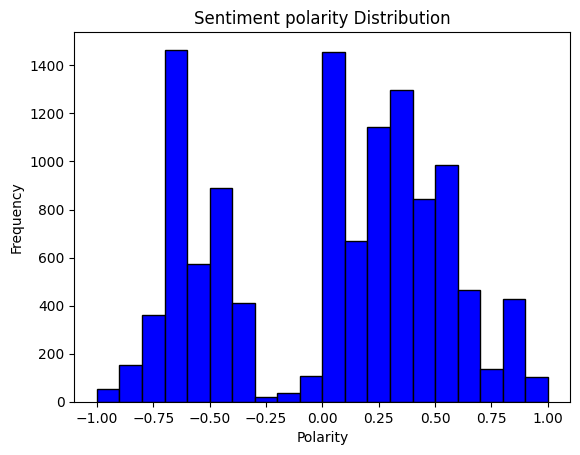

In [23]:
#Plot Histogram
plt.hist(df['polarity'], bins=20, color='blue', edgecolor='black')
plt.title('Sentiment polarity Distribution')
plt.xlabel('Polarity')
plt.ylabel('Frequency')
plt.show()


##Assessment: Experimentations (Using Machine Learning)

In [24]:
#Vectorization
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['comments'])

In [25]:
#Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, df['sentiment'], test_size=0.2, random_state=42)

In [26]:
print("Features X_train:")
X_train

Features X_train:


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 340530 stored elements and shape (9270, 32360)>

In [27]:
print("Features X_test:")
X_test

Features X_test:


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 84418 stored elements and shape (2318, 32360)>

In [28]:
print("Features y_train:")
y_train

Features y_train:


,sentiment
2030,negative
9847,positive
7401,neutral
4574,neutral
4219,neutral
...,...
11284,positive
5191,neutral
5390,neutral
860,negative


In [29]:
print("Features y_test:")
y_test

Features y_test:


,sentiment
6861,neutral
9774,positive
1272,negative
5118,neutral
9696,positive
...,...
788,negative
6935,neutral
3379,negative
11086,positive


## 1. Logistic Regression

In [30]:
print("Evaluation for: Logistic Regression Classifier".center(80,'_'))

lgc = LogisticRegression()
lgc.fit(X_train, y_train)

lgc_pred = lgc.predict(X_test)
lgc_acc = accuracy_score(y_test, lgc_pred)
lgc_prec = precision_score(y_test, lgc_pred, average="weighted")
lgc_rec = recall_score(y_test, lgc_pred, average="weighted")
lgc_f1 = f1_score(y_test, lgc_pred, average="weighted")

print(f"Model Type: {lgc}")
print("\n" + f"prediction: {lgc_pred}")
print('_' * 80)

print(f"Accuracy Score: {(lgc_acc):%}")
print(f"Precision Score: {(lgc_prec):%}")
print(f"Recall Score: {(lgc_rec):%}")
print(f"F1-Score: {(lgc_f1):%}")

_________________Evaluation for: Logistic Regression Classifier_________________
Model Type: LogisticRegression()

prediction: ['neutral' 'positive' 'negative' ... 'negative' 'positive' 'neutral']
________________________________________________________________________________
Accuracy Score: 87.057808%
Precision Score: 87.095362%
Recall Score: 87.057808%
F1-Score: 87.027914%


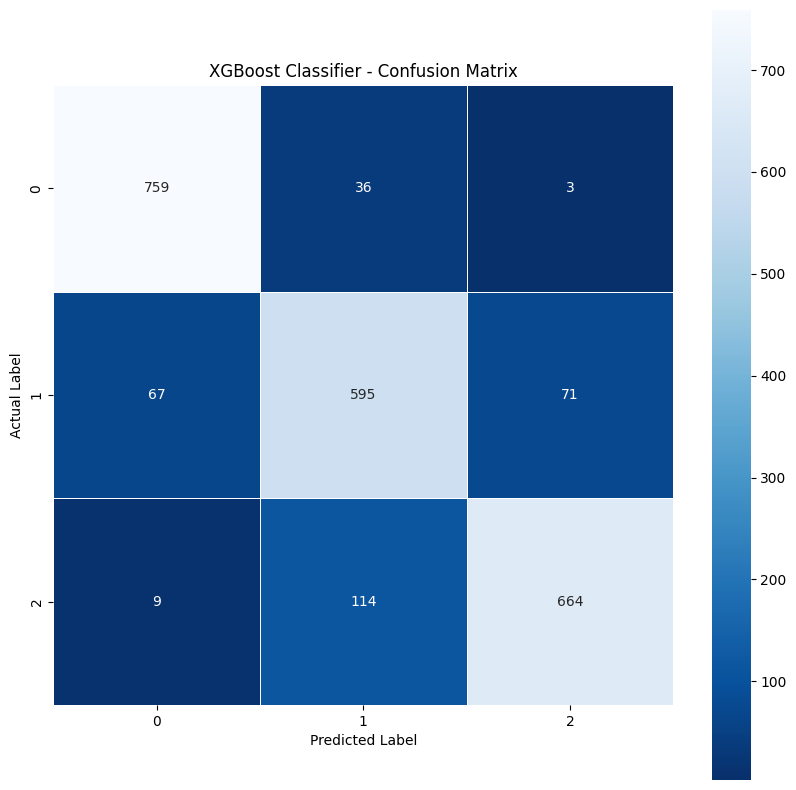

In [31]:
#Plotting the Confusion Matrix:
lgc_confusion_matrix = confusion_matrix(y_test, lgc_pred)

plt.figure(figsize=(10, 10))
sns.heatmap(lgc_confusion_matrix, annot=True, fmt='.0f', linewidths=0.7, square=True, cmap='Blues_r')
plt.title('XGBoost Classifier - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [32]:
print("Classification Report For XGBoost Classifier:")
print('-' * 57)
print(classification_report(y_test, lgc_pred))

Classification Report For XGBoost Classifier:
---------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.91      0.95      0.93       798
     neutral       0.80      0.81      0.81       733
    positive       0.90      0.84      0.87       787

    accuracy                           0.87      2318
   macro avg       0.87      0.87      0.87      2318
weighted avg       0.87      0.87      0.87      2318



In [33]:
import os

# Create the 'Models' directory if it doesn't exist
output_dir = 'Models'
os.makedirs(output_dir, exist_ok=True)

#Save the Logistic regression model
joblib.dump(lgc, os.path.join(output_dir, 'logistic_regression_model.pkl'))

['Models/logistic_regression_model.pkl']

In [34]:
#save the vectorizer
joblib.dump(vectorizer, 'Models/tfidf_vectorizer.pkl')

['Models/tfidf_vectorizer.pkl']

## 3. AdaBoost Classifier

In [35]:
print("Evaluation for: AdaBoost Clasifier".center(57, '_'))

abc = AdaBoostClassifier()
abc.fit(X_train, y_train)

abc_pred = abc.predict(X_test)
abc_acc = accuracy_score(y_test, abc_pred)
abc_prec = precision_score(y_test, abc_pred, average="weighted")
abc_rec = recall_score(y_test, abc_pred, average="weighted")
abc_f1 = f1_score(y_test, abc_pred, average="weighted")

print(f"Model Type: {abc}")
print(f"Prediction: {abc_pred}")
print('-' * 57)


print(f"Accuracy Score: {(abc_acc):%}")
print(f"Precision Score: {(abc_prec):%}")
print(f"Recall Score: {(abc_rec):%}")
print(f"F1-Score: {(abc_f1):%}")

____________Evaluation for: AdaBoost Clasifier___________
Model Type: AdaBoostClassifier()
Prediction: ['neutral' 'neutral' 'negative' ... 'negative' 'positive' 'neutral']
---------------------------------------------------------
Accuracy Score: 74.762726%
Precision Score: 78.108841%
Recall Score: 74.762726%
F1-Score: 75.436342%


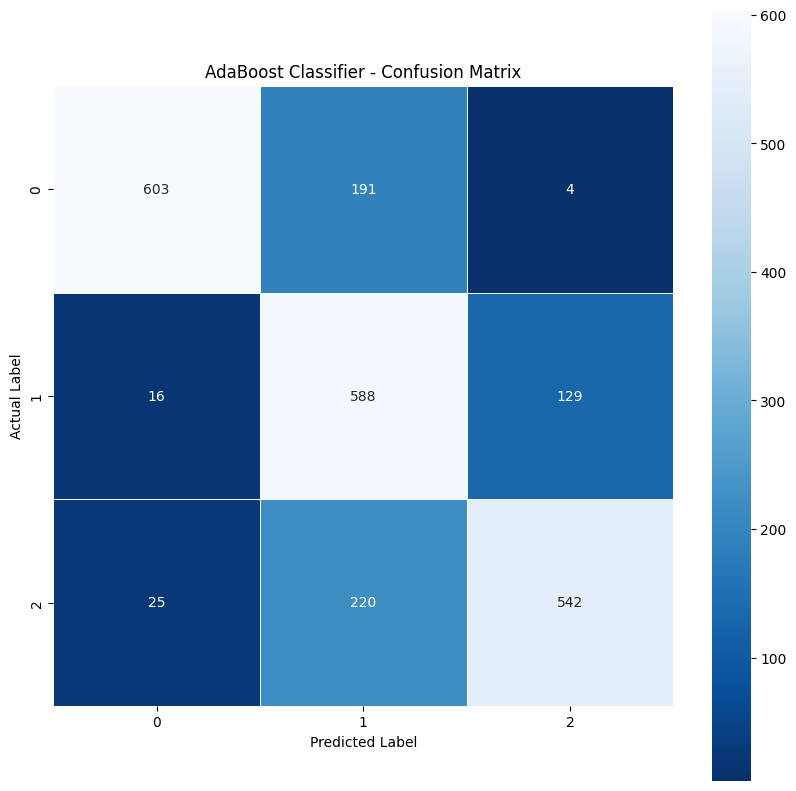

In [36]:
#Plotting the Confusion Matrix:
abc_confusion_matrix = confusion_matrix(y_test, abc_pred)

plt.figure(figsize=(10, 10))
sns.heatmap(abc_confusion_matrix, annot=True, fmt='.0f', linewidths=0.7, square=True, cmap="Blues_r")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.title("AdaBoost Classifier - Confusion Matrix")
plt.show()

In [37]:
print("Classification Report for AdaBoost Classifier:")
print('-' * 57)
print(classification_report(y_test, abc_pred))

Classification Report for AdaBoost Classifier:
---------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.94      0.76      0.84       798
     neutral       0.59      0.80      0.68       733
    positive       0.80      0.69      0.74       787

    accuracy                           0.75      2318
   macro avg       0.78      0.75      0.75      2318
weighted avg       0.78      0.75      0.75      2318



In [38]:
#save the logistic regression model
joblib.dump(abc, 'Models/ada_boost_model.pkl')

['Models/ada_boost_model.pkl']

##3. K-Nearest Neighbours

In [39]:
print("Evaluation for: K-Nearest Neighbours".center(57, '_'))

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
knn_prec = precision_score(y_test, knn_pred, average="weighted")
knn_rec = recall_score(y_test, knn_pred, average="weighted")
k_f1 = f1_score(y_test, knn_pred, average="weighted")

print(f"Model Type: {knn}")
print(f"Prediction: {knn_pred}")
print(f'-' * 57)

print(f"Accuracy Score: {(knn_acc):%}")
print(f"Precision Score: {(knn_prec):%}")
print(f"Recall Score: {(knn_rec):%}")
print(f"F1-Score: {(k_f1):%}")

___________Evaluation for: K-Nearest Neighbours__________
Model Type: KNeighborsClassifier()
Prediction: ['neutral' 'positive' 'neutral' ... 'negative' 'positive' 'neutral']
---------------------------------------------------------
Accuracy Score: 69.197584%
Precision Score: 71.072266%
Recall Score: 69.197584%
F1-Score: 69.684004%


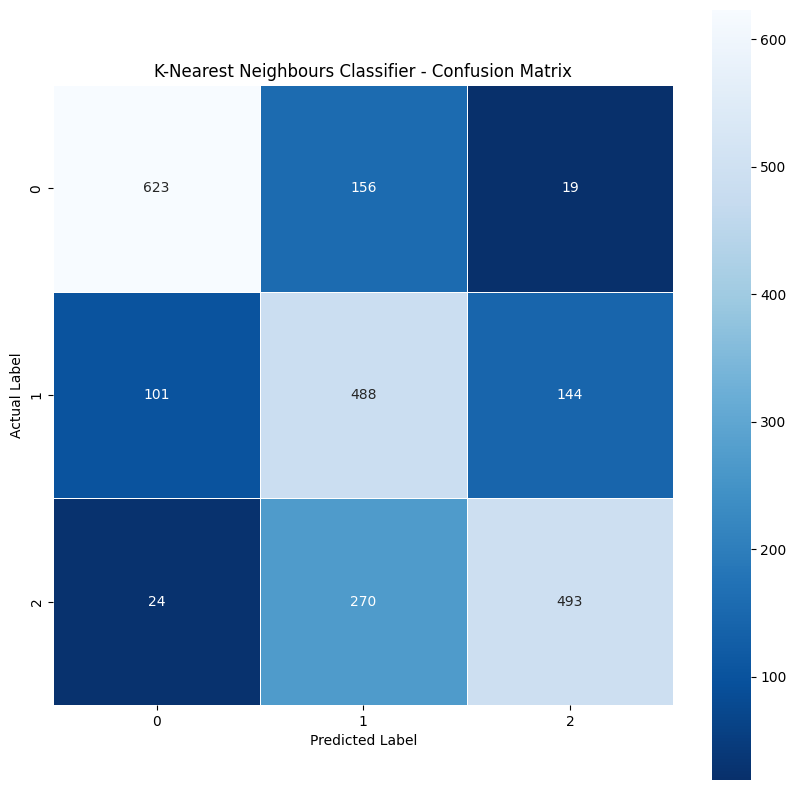

In [40]:
#Plotting the Confusion Matrix:
knn_confusion_matrix = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(10, 10))
sns.heatmap(knn_confusion_matrix, annot=True, fmt='.0f', linewidths=0.7, square=True, cmap="Blues_r")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.title("K-Nearest Neighbours Classifier - Confusion Matrix")
plt.show()

In [41]:
print("Classification Report For K-Neighburs Classifier")
print('-' * 57)
print(classification_report(y_test, knn_pred))

Classification Report For K-Neighburs Classifier
---------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.83      0.78      0.81       798
     neutral       0.53      0.67      0.59       733
    positive       0.75      0.63      0.68       787

    accuracy                           0.69      2318
   macro avg       0.71      0.69      0.69      2318
weighted avg       0.71      0.69      0.70      2318



In [42]:
#save the k-neighbours model
joblib.dump(knn, 'Models/k_neighnors_model.pkl')

['Models/k_neighnors_model.pkl']

##4. Decison Tree Classifier

In [43]:
from sklearn.tree import DecisionTreeClassifier

print("Evaluation for: Decision Tree Classifier".center(57, '_'))
dtc = DecisionTreeClassifier()

dtc.fit(X_train, y_train)

dtc_pred = dtc.predict(X_test)
dtc_acc = accuracy_score(y_test, dtc_pred)
dtc_prec = precision_score(y_test, dtc_pred, average="weighted")
dtc_rec = recall_score(y_test, dtc_pred, average="weighted")
dtc_f1 = f1_score(y_test, dtc_pred, average="weighted")

print(f"Model Type: {dtc}")
print(f"Prediction: {dtc_pred}")
print('-' * 57)

print(f"Accuracy Score: {(dtc_acc):%}")
print(f"Precision Score: {(dtc_prec):%}")
print(f"Recall Score: {(dtc_rec):%}")
print(f"F1_Score: {(dtc_f1):%}")

_________Evaluation for: Decision Tree Classifier________
Model Type: DecisionTreeClassifier()
Prediction: ['neutral' 'positive' 'negative' ... 'negative' 'positive' 'neutral']
---------------------------------------------------------
Accuracy Score: 84.210526%
Precision Score: 84.325090%
Recall Score: 84.210526%
F1_Score: 84.253461%


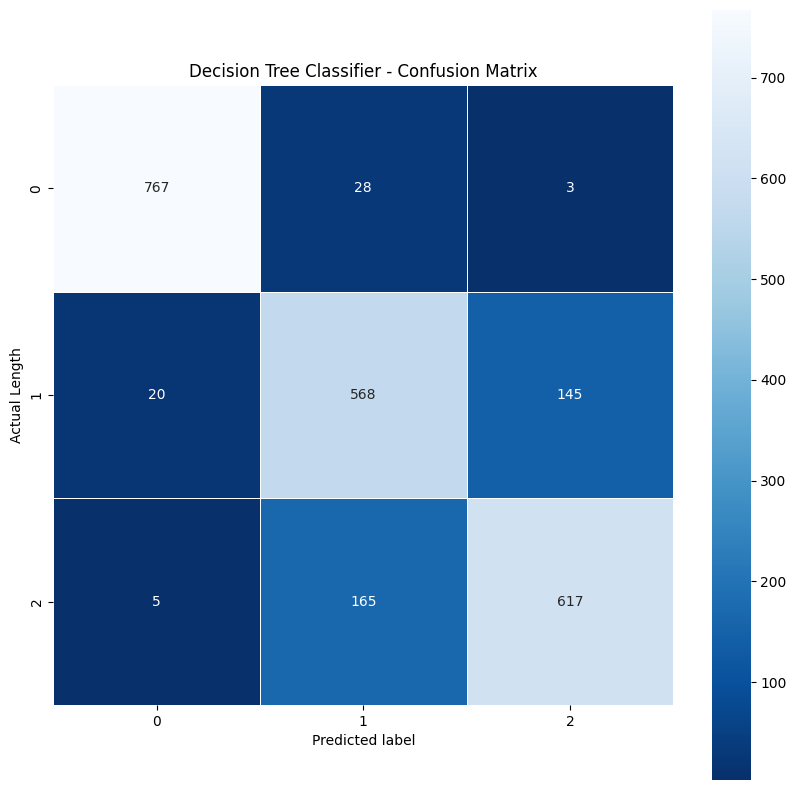

In [44]:
#Plotting the Confusion Matrix:
dtc_confusion_matrix = confusion_matrix(y_test, dtc_pred)

plt.figure(figsize=(10, 10))
sns.heatmap(dtc_confusion_matrix, annot=True, fmt=".0f", linewidths=0.7, square=True, cmap='Blues_r')
plt.ylabel("Actual Length")
plt.xlabel("Predicted label")
plt.title("Decision Tree Classifier - Confusion Matrix")
plt.show()

In [45]:
print("Classification Report For Decision Tree Classifier:")
print('-' * 57)
print(classification_report(y_test, dtc_pred))

Classification Report For Decision Tree Classifier:
---------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.97      0.96      0.96       798
     neutral       0.75      0.77      0.76       733
    positive       0.81      0.78      0.80       787

    accuracy                           0.84      2318
   macro avg       0.84      0.84      0.84      2318
weighted avg       0.84      0.84      0.84      2318



In [46]:
#save the decision tree model
joblib.dump(dtc, 'Models/decision_tree_model.pkl')

['Models/decision_tree_model.pkl']

##5. Random Forest Classifier

In [47]:
from sklearn.ensemble import RandomForestClassifier

print("Evaluation for: Random Forest Classifier".center(57, '_'))

rfc = RandomForestClassifier()

rfc.fit(X_train, y_train)

rfc_pred = rfc.predict(X_test)
rfc_acc = accuracy_score(y_test, rfc_pred)
rfc_prec = precision_score(y_test, rfc_pred, average="weighted")
rfc_rec = recall_score(y_test, rfc_pred, average="weighted")
rfc_f1 = f1_score(y_test, rfc_pred, average="weighted")

print(f"Model Type: {rfc}")
print(f"Prediction: {rfc_pred}")
print('-' * 57)

print(f"Accuracy Score: {(rfc_acc):%}")
print(f"Precision Score: {(rfc_prec):%}")
print(f"Recall Score: {(rfc_rec):%}")
print(f"F1 Score: {(rfc_f1):%}")

_________Evaluation for: Random Forest Classifier________
Model Type: RandomForestClassifier()
Prediction: ['positive' 'positive' 'negative' ... 'negative' 'positive' 'neutral']
---------------------------------------------------------
Accuracy Score: 80.241588%
Precision Score: 80.205319%
Recall Score: 80.241588%
F1 Score: 79.841664%


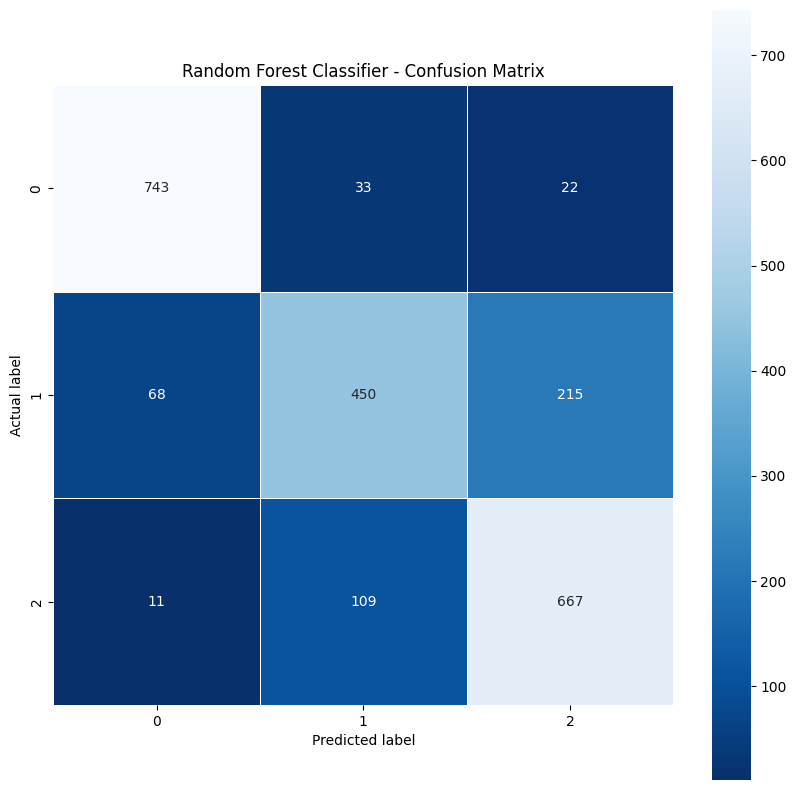

In [48]:
#Plotting the Confusion Matrix:
rfc_confusion_matrix = confusion_matrix(y_test, rfc_pred)

plt.figure(figsize=(10, 10))
sns.heatmap(rfc_confusion_matrix, annot=True, fmt=".0f", linewidths=0.7, square=True, cmap="Blues_r")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.title("Random Forest Classifier - Confusion Matrix")
plt.show()

In [49]:
print("Classification Report For Random Forest Classifier")
print('-' * 57)
print(classification_report(y_test, rfc_pred))

Classification Report For Random Forest Classifier
---------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.90      0.93      0.92       798
     neutral       0.76      0.61      0.68       733
    positive       0.74      0.85      0.79       787

    accuracy                           0.80      2318
   macro avg       0.80      0.80      0.80      2318
weighted avg       0.80      0.80      0.80      2318



In [51]:
#save the Random Forest model
joblib.dump(rfc, 'Models/random_forest_model.pkl')

['Models/random_forest_model.pkl']

##6. Gradient Boosting Classifier

In [53]:
print("Evaluation for: Gradient Boosting Classifier".center(57, '_'))
gbc = GradientBoostingClassifier()

gbc.fit(X_train, y_train)

gbc_pred = gbc.predict(X_test)
gbc_acc = accuracy_score(y_test, gbc_pred)
gbc_prec = precision_score(y_test, gbc_pred, average="weighted")
gbc_rec = recall_score(y_test, gbc_pred, average="weighted")
gbc_f1 = f1_score(y_test, gbc_pred, average="weighted")

print(f"Model Type: {gbc}")
print(f"Prediction: {gbc_pred}")
print('-' * 57)

print(f"Accuracy Score: {(gbc_acc):%}")
print(f"Precision Score: {(gbc_prec):%}")
print(f"Recall Score: {(gbc_rec):%}")
print(f"F1 Score: {(gbc_f1):%}")

_______Evaluation for: Gradient Boosting Classifier______
Model Type: GradientBoostingClassifier()
Prediction: ['neutral' 'neutral' 'negative' ... 'negative' 'positive' 'neutral']
---------------------------------------------------------
Accuracy Score: 87.014668%
Precision Score: 87.558830%
Recall Score: 87.014668%
F1 Score: 87.176892%


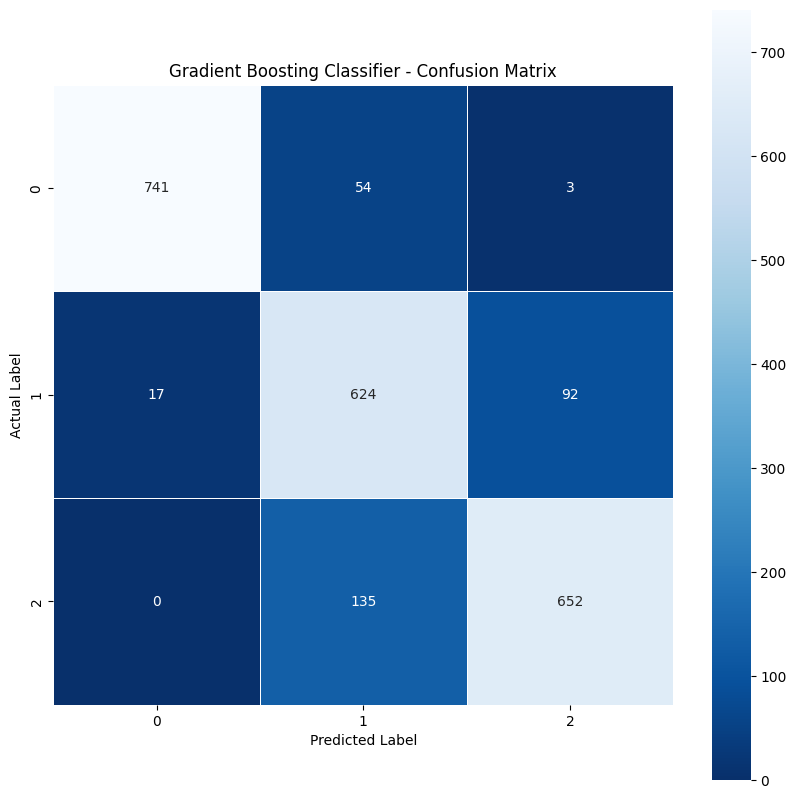

In [56]:
#Plotting the Confusion Matrix:
gbc_confusion_matrix = confusion_matrix(y_test, gbc_pred)

plt.figure(figsize=(10, 10))
sns.heatmap(gbc_confusion_matrix, annot=True, fmt=".0f", linewidths=0.7, square=True, cmap="Blues_r")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.title("Gradient Boosting Classifier - Confusion Matrix")
plt.show()


In [57]:
print("Classification Report for Gradient Bosting Classifier:")
print('-' * 57)
print(classification_report(y_test, gbc_pred))

Classification Report for Gradient Bosting Classifier:
---------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.98      0.93      0.95       798
     neutral       0.77      0.85      0.81       733
    positive       0.87      0.83      0.85       787

    accuracy                           0.87      2318
   macro avg       0.87      0.87      0.87      2318
weighted avg       0.88      0.87      0.87      2318



In [58]:
#save the gradient boosting model
joblib.dump(gbc, 'Models/gradient_bosting_model.pkl')

['Models/gradient_bosting_model.pkl']

##7. C-Support Vector Classifier

In [55]:
print("Evaluation for: C-Support Vector Classification".center(57, '_'))

svc = SVC()

svc.fit(X_train, y_train)

svc_pred = svc.predict(X_test)
svc_acc = accuracy_score(y_test, svc_pred)
svc_prec = precision_score(y_test, svc_pred, average="weighted")
svc_rec = recall_score(y_test, svc_pred, average="weighted")
svc_f1 = f1_score(y_test, svc_pred, average="weighted")

print(f"Model Type: {svc}")
print(f"Prediction: {svc_pred}")
print('-' * 57)

print(f"Accuracy Score: {(svc_acc):%}")
print(f"Precision Score: {(svc_prec):%}")
print(f"Recall Score: {(svc_rec):%}")
print(f"F1_score: {(svc_f1):%}")

_____Evaluation for: C-Support Vector Classification_____
Model Type: SVC()
Prediction: ['neutral' 'positive' 'negative' ... 'negative' 'positive' 'neutral']
---------------------------------------------------------
Accuracy Score: 87.704918%
Precision Score: 87.959352%
Recall Score: 87.704918%
F1_score: 87.706170%


<function matplotlib.pyplot.show(close=None, block=None)>

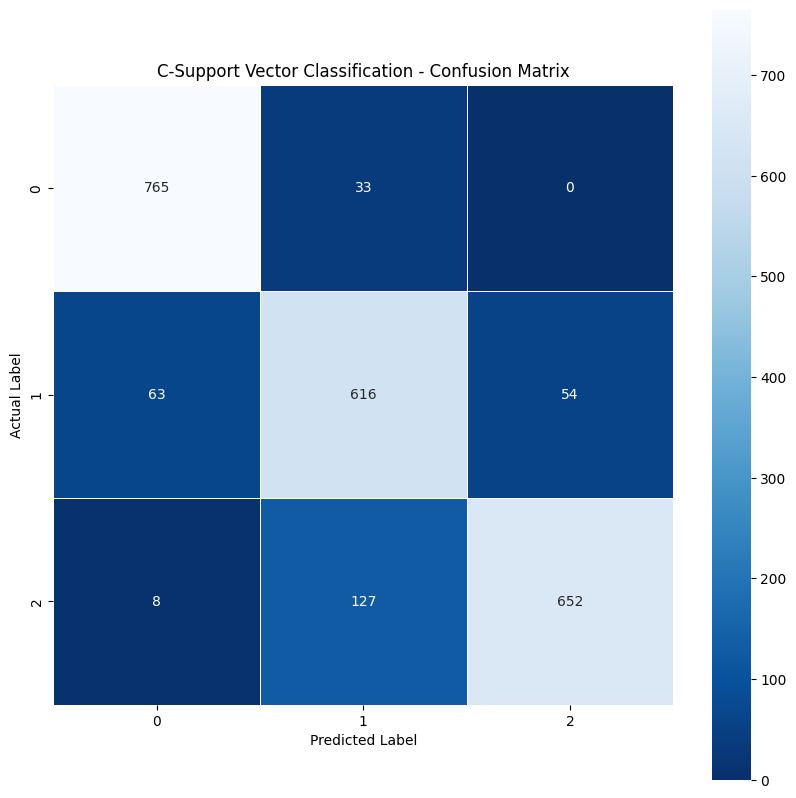

In [59]:
#Plotting the confusion matrix
svc_confusion_matrix = confusion_matrix(y_test, svc_pred)

plt.figure(figsize=(10, 10))
sns.heatmap(svc_confusion_matrix, annot=True, fmt=".0f", linewidths=0.7, square=True, cmap="Blues_r")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.title("C-Support Vector Classification - Confusion Matrix")
plt.show

In [60]:
print("Classification Report For C-Support Vector Classification:")
print('-' * 63)
print(classification_report(y_test, svc_pred))

Classification Report For C-Support Vector Classification:
---------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.92      0.96      0.94       798
     neutral       0.79      0.84      0.82       733
    positive       0.92      0.83      0.87       787

    accuracy                           0.88      2318
   macro avg       0.88      0.88      0.88      2318
weighted avg       0.88      0.88      0.88      2318



In [61]:
#Save the c-support vector model
joblib.dump(svc, 'Models/c_support_vector_model.pkl')

['Models/c_support_vector_model.pkl']

##Visualizing the Metric Scores for all Classifier

In [63]:
lgc_scores = [lgc_acc*100, lgc_prec*100, lgc_rec*100, lgc_f1*100]
abc_scores = [abc_acc*100, abc_prec*100, abc_rec*100, abc_f1*100]
knn_scores = [knn_acc*100, knn_prec*100, knn_rec*100, k_f1*100]
dtc_scores = [dtc_acc*100, dtc_prec*100, dtc_rec*100, dtc_f1*100]
rfc_scores = [rfc_acc*100, rfc_prec*100, rfc_rec*100, rfc_f1*100]
gbc_scores = [gbc_acc*100, gbc_prec*100, gbc_rec*100, gbc_f1*100]
svc_scores = [svc_acc*100, svc_prec*100, svc_rec*100, svc_f1*100]

x_grid = ["Accuracy", "Precision", "Recall", "F1-Score"]
y_grid = [value for value in range(1, 120, 10)]
xpos = np.arange(len(x_grid))
bar_width = .10

plt.figure(figsize=(20, 10), dpi=700, facecolor='w', edgecolor='k')
plt.title("Model Evaluation Scores", fontsize=20)
#Function to add value labels on the bars

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.2f}%', ha='center', va='bottom', rotation=90)

#Creating bars and adding labels
bars_lgc = plt.bar(xpos, lgc_scores, width=bar_width,
                   label="Logistic Regression")
add_labels(bars_lgc)

bars_abc = plt.bar(xpos + bar_width, abc_scores, width=bar_width,
                   label="AdaBoost Classifier")
add_labels(bars_abc)

bars_knn = plt.bar(xpos + 2*bar_width, knn_scores, width=bar_width,
                   label="K-Nearest Neighbours")
add_labels(bars_knn)

bars_dtc = plt.bar(xpos + 3*bar_width, dtc_scores, width=bar_width,
                   label="Decision Tree Classifier")
add_labels(bars_dtc)

bars_rfc = plt.bar(xpos + 4*bar_width, rfc_scores, width=bar_width,
                   label="Random Forest Classifier")
add_labels(bars_rfc)

bars_gbc = plt.bar(xpos + 5*bar_width, gbc_scores, width=bar_width,
                   label="Gradient Boosting Classifier")
add_labels(bars_gbc)

bars_svc = plt.bar(xpos + 6*bar_width, svc_scores, width=bar_width,
                   label="C-Support Vector Classifier")
add_labels(bars_svc)

plt.xticks(xpos + bar_width*3, x_grid, fontsize=15)
plt.yticks(y_grid, fontsize=15)
plt.xlabel("Evaluation Metrics", fontsize=20)
plt.ylabel("Percentage", fontsize=20)
plt.legend(bbox_to_anchor=(1.15, 1), borderaxespad=0.)
plt.show()